In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("/content/drive/MyDrive/Telco_customer_churn.xlsx")

In [3]:
df.shape

(7043, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


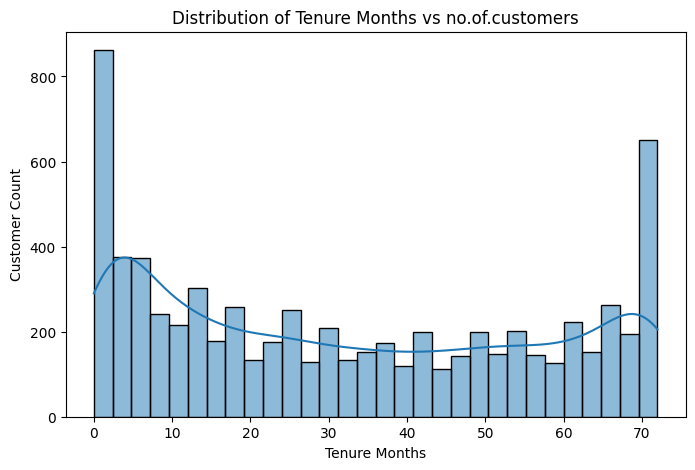

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'], bins= 30, kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer Count')
plt.title('Distribution of Tenure Months vs no.of.customers')
plt.show()

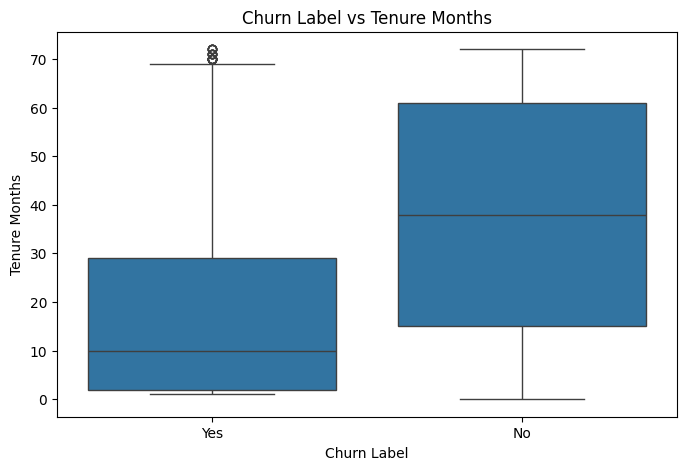

In [7]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn Label', y = 'Tenure Months', data = df)
plt.xlabel('Churn Label')
plt.ylabel('Tenure Months')
plt.title('Churn Label vs Tenure Months')
plt.show()

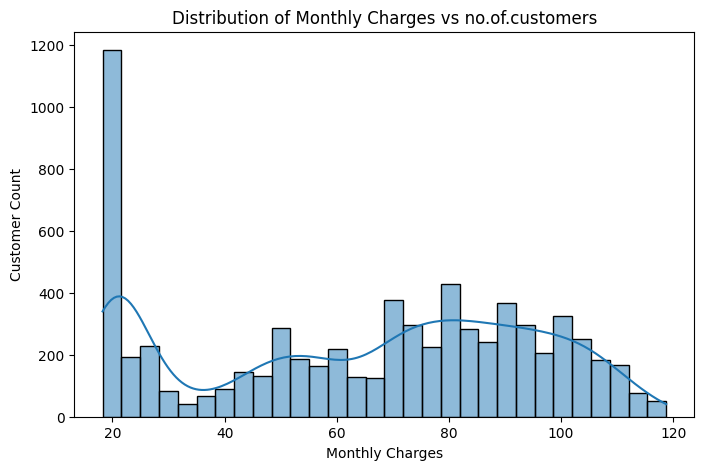

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'], bins= 30, kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer Count')
plt.title('Distribution of Monthly Charges vs no.of.customers')
plt.show()

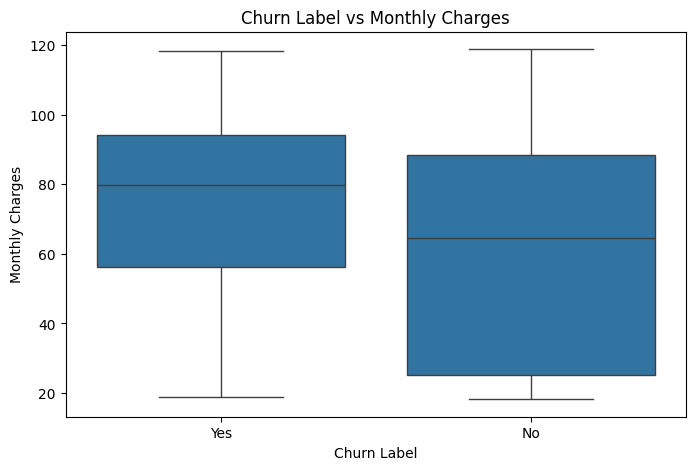

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x = 'Churn Label', y = 'Monthly Charges', data = df)
plt.xlabel('Churn Label')
plt.ylabel('Monthly Charges')
plt.title('Churn Label vs Monthly Charges')
plt.show()

In [10]:
df[df["Churn Label"] == 'Yes']["Monthly Charges"].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [11]:
df[df["Churn Label"] == 'No']["Monthly Charges"].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [12]:
df["Monthly Charges"].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [13]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

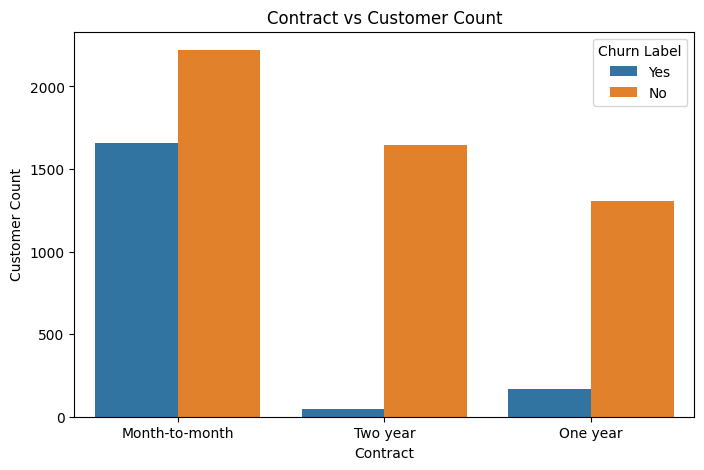

In [14]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Contract', hue = 'Churn Label', data = df)
plt.xlabel('Contract')
plt.ylabel('Customer Count')
plt.title('Contract vs Customer Count')
plt.show()

In [15]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

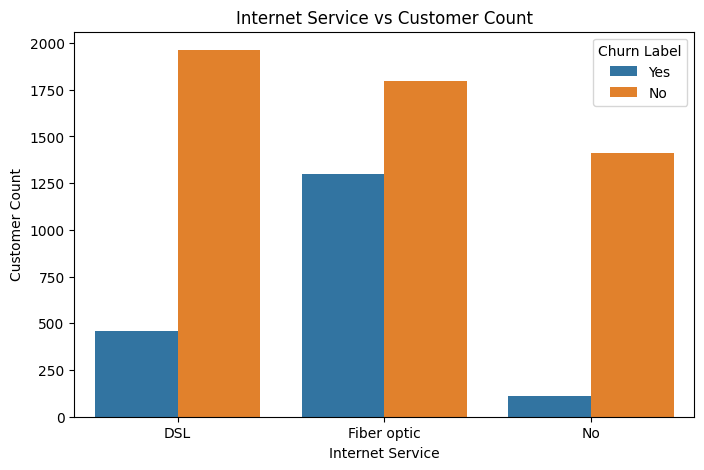

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Internet Service', hue = 'Churn Label', data = df)
plt.xlabel('Internet Service')
plt.ylabel('Customer Count')
plt.title('Internet Service vs Customer Count')
plt.show()

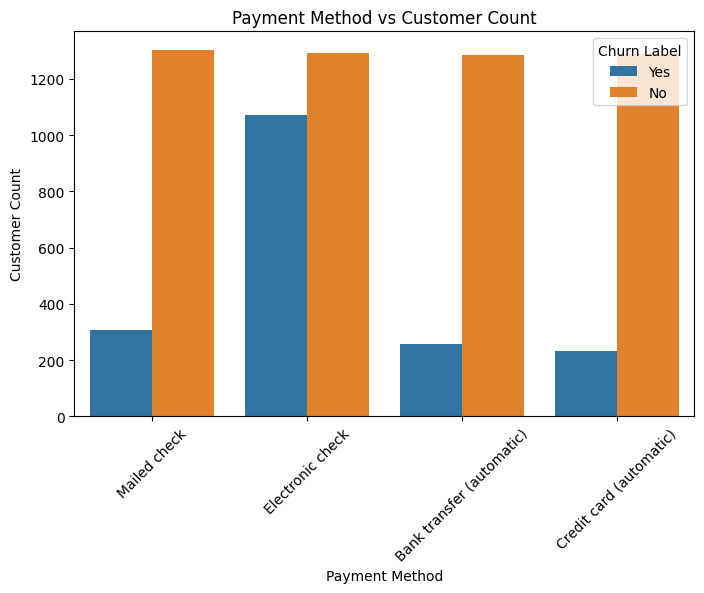

In [17]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Payment Method', hue = 'Churn Label', data = df)
plt.xlabel('Payment Method')
plt.ylabel('Customer Count')
plt.xticks(rotation = 45)
plt.title('Payment Method vs Customer Count')
plt.show()

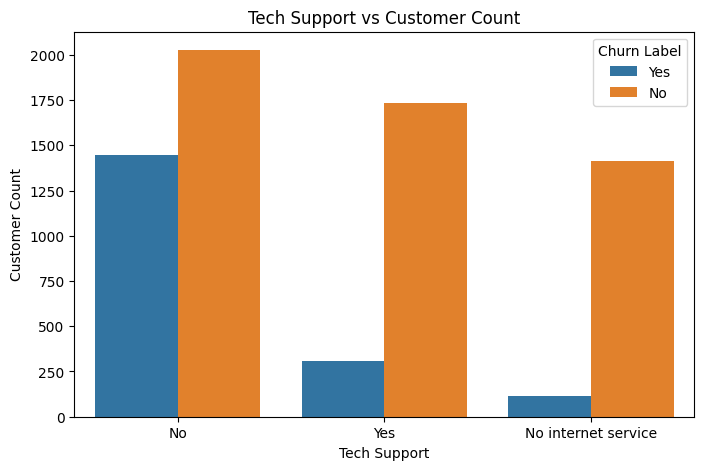

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x = 'Tech Support', hue = 'Churn Label', data = df)
plt.xlabel('Tech Support')
plt.ylabel('Customer Count')
plt.title('Tech Support vs Customer Count')
plt.show()

In [19]:
avg_tenure = df.groupby(["Churn Label"])["Tenure Months"].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [20]:
numerical_columns = ['Tenure Months','Monthly Charges', 'Churn Value', 'Churn Score', 'CLTV']
correlation_matrix = df[numerical_columns].corr()
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [21]:
pd.crosstab(df['Contract'], df['Churn Label'], normalize= 'index')

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Data Cleaning**

In [22]:
df['Total Charges'] =  pd.to_numeric(df['Total Charges'], errors='coerce')

In [23]:
df['Total Charges'].dtype

dtype('float64')

In [24]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [25]:
df['Tenure Months'][df['Total Charges'].isnull()]

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [26]:
df['Total Charges'] = df['Total Charges'].fillna(0)

In [27]:
drop_columns = ['CustomerID', 'Count', 'Country', 'State', 'Lat Long', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Churn Score', 'CLTV', 'Churn Reason', 'Churn Score']
df.drop(columns = drop_columns, inplace = True)


In [28]:
df.shape

(7043, 22)

In [29]:
df_encoded = pd.get_dummies(data = df, drop_first= True)
df_encoded.shape

(7043, 1160)

In [30]:
df = df.drop(columns= ["City"])

In [31]:
df.drop(columns= ["Churn Label"], inplace = True)

In [32]:
df_encoded = pd.get_dummies(data = df, drop_first= True)
df_encoded.shape

(7043, 31)

In [33]:
x = df_encoded.drop(columns= ["Churn Value"])
y = df_encoded["Churn Value"]

Machine Learning Implementation

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [35]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest Classifier Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")

Random Forest Classifier Accuracy: 0.7857


In [38]:
cm = confusion_matrix(y_test, y_pred_rf)
report = classification_report(y_test, y_pred_rf)
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

Confusion Matrix:
[[902 107]
 [195 205]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



Approach - 1 : Handle class Imbalance

In [39]:
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_balanced.fit(X_train, y_train)
y_pred_rf_balanced = rf_balanced.predict(X_test)
print(f"Random Forest Classifier (Balanced) Accuracy: {accuracy_score(y_test, y_pred_rf_balanced):.4f}")
print("\nClassification Report (Balanced):")
print(classification_report(y_test, y_pred_rf_balanced))
print("\nConfusion Matrix (Balanced):")
print(confusion_matrix(y_test, y_pred_rf_balanced))

Random Forest Classifier (Balanced) Accuracy: 0.7921

Classification Report (Balanced):
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix (Balanced):
[[907 102]
 [191 209]]


Approach - 2 : Hyperparameter tuning

In [40]:
rf_tuned= RandomForestClassifier(n_estimators=300, max_depth = 10, random_state=42, class_weight="balanced")
rf_tuned.fit(X_train, y_train)
y_pred_rf_tuned = rf_tuned.predict(X_test)
print(f"Random Forest Classifier (Tuned) Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print("\nClassification Report (Tuned):")
print(classification_report(y_test, y_pred_rf_tuned))
print("\nConfusion Matrix (Tuned):")
print(confusion_matrix(y_test, y_pred_rf_tuned))


Random Forest Classifier (Tuned) Accuracy: 0.7828

Classification Report (Tuned):
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409


Confusion Matrix (Tuned):
[[804 205]
 [101 299]]


Approach 3 : Feature Importance Analysis

In [41]:
features_selected = pd.DataFrame({'Feature': x.columns, 'Importance': rf.feature_importances_})
features_selected = features_selected.sort_values(by='Importance', ascending=False)
features_selected

,Feature,Importance
2,Total Charges,0.190197
0,Tenure Months,0.173457
1,Monthly Charges,0.167753
28,Payment Method_Electronic check,0.038823
6,Dependents_Yes,0.035459
10,Internet Service_Fiber optic,0.034156
25,Contract_Two year,0.029158
3,Gender_Male,0.027464
5,Partner_Yes,0.025513
26,Paperless Billing_Yes,0.025163


In [42]:
x_selected = x.drop(columns = ["Phone Service_Yes", "Multiple Lines_No phone service"])

In [43]:
X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(x_selected, y, test_size=0.2, random_state=42)

In [44]:
rf_selected = RandomForestClassifier(n_estimators=300, max_depth = 10, random_state=42, class_weight="balanced")
rf_selected.fit(X_train_selected, y_train_selected)
y_pred_rf_selected = rf_selected.predict(X_test_selected)
print(f"Random Forest Classifier (Selected Features) Accuracy: {accuracy_score(y_test_selected, y_pred_rf_selected):.4f}")
print("\nClassification Report (Selected Features):")
print(classification_report(y_test_selected, y_pred_rf_selected))

Random Forest Classifier (Selected Features) Accuracy: 0.7835

Classification Report (Selected Features):
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



Approach 2 Combination of trees and depths

In [45]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

In [46]:
n_estimators = [100, 200, 300, 400, 500]
max_depths = [5, 10, 15, 20]
result = []
for n in n_estimators:
    for d in max_depths:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42, class_weight="balanced")
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        result.append({'n_estimators': n, 'max_depth': d, 'accuracy': accuracy, 'recall': recall, 'precision': precision, 'f1_score': f1})

result_df = pd.DataFrame(result)
result_df = result_df.sort_values(by=['recall','accuracy'], ascending=False)
result_df

,n_estimators,max_depth,accuracy,recall,precision,f1_score
0,100,5,0.745919,0.8200,0.534202,0.646943
8,300,5,0.743790,0.8200,0.531605,0.645034
12,400,5,0.743790,0.8125,0.531915,0.642928
4,200,5,0.742370,0.8100,0.530278,0.640950
16,500,5,0.740951,0.8050,0.528736,0.638256
1,100,10,0.775727,0.7525,0.581081,0.655773
9,300,10,0.782825,0.7475,0.593254,0.661504
13,400,10,0.782825,0.7475,0.593254,0.661504
17,500,10,0.781405,0.7475,0.590909,0.660044
5,200,10,0.782115,0.7450,0.592445,0.660022


From the above results we can take the parameters (n_estimators, max_depth) as either (300,10) or (400,10) which has identical values for all the parameters.  (300,10) is our rf_tuned so we take it as our final model

In [47]:
from sklearn.model_selection import cross_val_score

In [48]:
cv_accuracy = cross_val_score(rf_tuned, x, y, cv=5, scoring='accuracy')
cv_recall = cross_val_score(rf_tuned, x, y, cv=5, scoring='recall')

In [49]:
cv_accuracy.mean()

np.float64(0.7793569343183432)

In [50]:
cv_recall.mean()

np.float64(0.7335350030823931)

In [51]:
from sklearn.metrics import roc_auc_score, roc_curve

In [52]:
y_proba = rf_tuned.predict_proba(X_test)[:, 1]
roc_auc_score(y_test, y_proba)


np.float64(0.857104806739346)

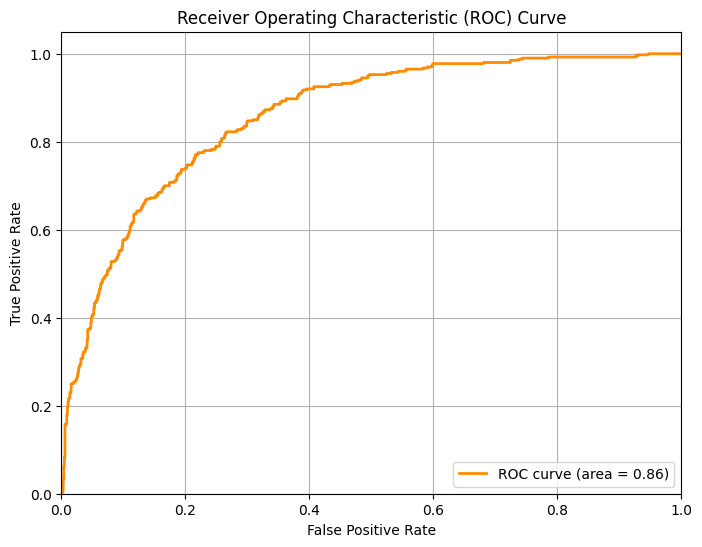

In [53]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

Customer Segmentation

In [54]:
churn_probability = rf_tuned.predict_proba(x)[:, 1]

In [55]:
segmentation_data = pd.DataFrame({
    'Tenure Months': df['Tenure Months'],
    'Monthly Charges': df['Monthly Charges'],
    'Total Charges': df['Total Charges'],
    'Churn Probability' : churn_probability
})

In [56]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [59]:
scaled_data = scaler.fit_transform(segmentation_data)

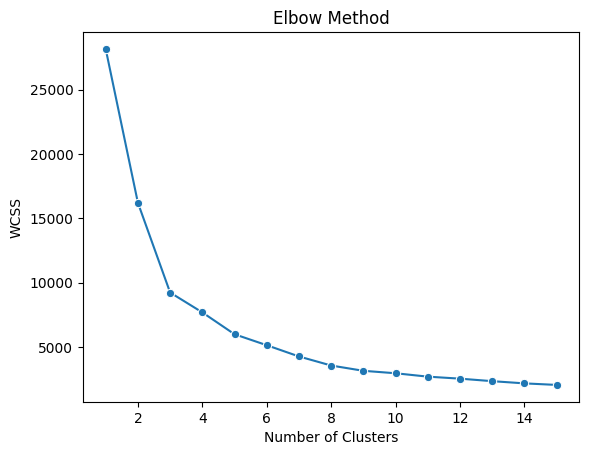

In [75]:
from sklearn.cluster import KMeans

wcss = []
k = range(1, 16)
for i in k:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

sns.lineplot(x=k, y=wcss, marker = 'o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [61]:
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
clusters = kmeans.fit_predict(scaled_data)

In [62]:
segmentation_data["Cluster"] = clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,1
1,2,70.70,151.65,0.796013,1
2,8,99.65,820.50,0.805827,1
3,28,104.80,3046.05,0.563031,1
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0
7039,24,84.80,1990.50,0.082095,0
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,0


In [64]:
cluster_summary = segmentation_data.groupby("Cluster").mean()
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [69]:
cluster_names = {
    0 : "Budget Loyal Customers",
    1 : "High Risk New Customers",
    2 : "Premium Loyal Customers"
}

In [70]:
segmentation_data["Cluster Segment"] = segmentation_data["Cluster"].map(cluster_names)

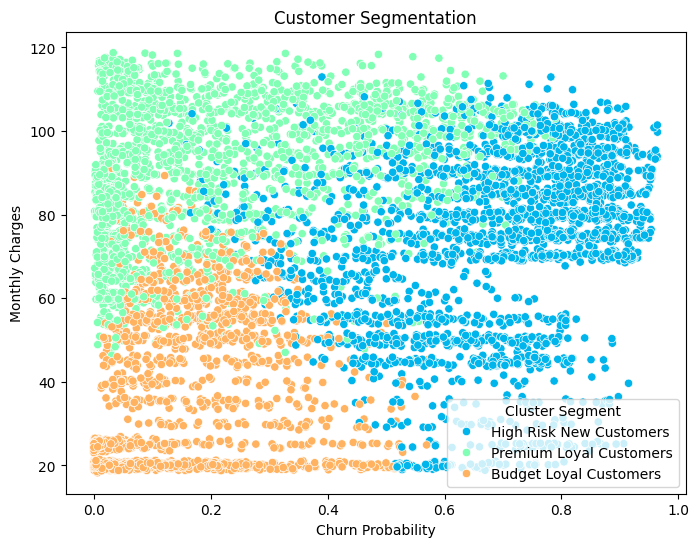

In [72]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Churn Probability', y='Monthly Charges', hue='Cluster Segment', data=segmentation_data, palette='rainbow')
plt.xlabel('Churn Probability')
plt.ylabel('Monthly Charges')
plt.title('Customer Segmentation')
plt.legend(title='Cluster Segment')
plt.show()

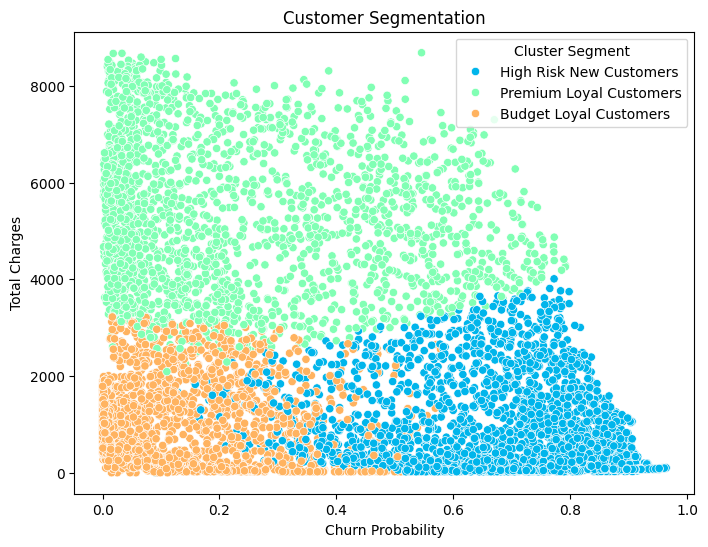

In [73]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Churn Probability', y='Total Charges', hue='Cluster Segment', data=segmentation_data, palette='rainbow')
plt.xlabel('Churn Probability')
plt.ylabel('Total Charges')
plt.title('Customer Segmentation')
plt.legend(title='Cluster Segment')
plt.show()

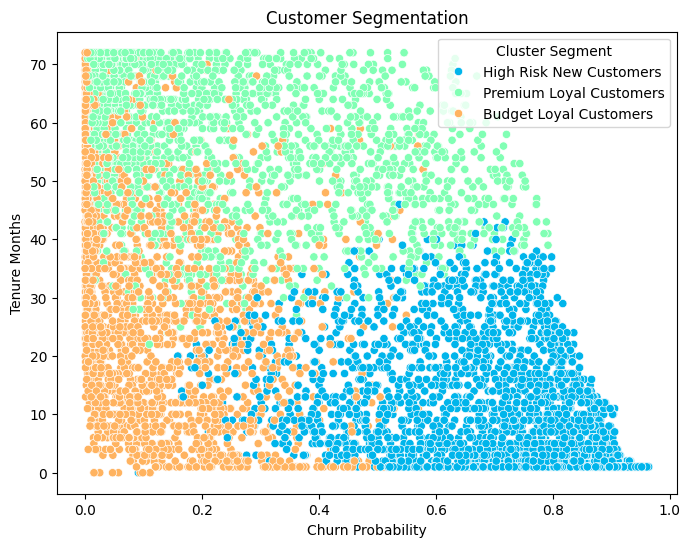

In [74]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Churn Probability', y='Tenure Months', hue='Cluster Segment', data=segmentation_data, palette='rainbow')
plt.xlabel('Churn Probability')
plt.ylabel('Tenure Months')
plt.title('Customer Segmentation')
plt.legend(title='Cluster Segment')
plt.show()